<a href="https://colab.research.google.com/github/munnurumahesh03-coder/-Aerial-Damage-AI/blob/main/Aerial_disaster_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==============================================================================
# Install Dependencies
# ==============================================================================
print("⏳ Installing Ultralytics and Roboflow...")
!pip install ultralytics roboflow sahi streamlit -q
print("✅ Installations complete!")


⏳ Installing Ultralytics and Roboflow...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 117.3 MB/s eta 0:00:00
✅ Installations complete!


In [2]:
# ==============================================================================
# Global Imports & Hardware Verification
# ==============================================================================
import os
import glob
import yaml
import random
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning & CV Libraries
import torch
from ultralytics import YOLO
from roboflow import Roboflow

# Make plots look professional
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

# Hardware Check
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"🚀 GPU Active: {gpu_name}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ WARNING: No GPU detected. Please check Colab runtime settings!")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries imported successfully!
🚀 GPU Active: Tesla T4
💾 GPU Memory: 15.64 GB


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="KpN2zwGXZ3EqIsSOgMMp")
project = rf.workspace("flow-wnra9").project("xview2-xbd")
version = project.version(10)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Xview2-XBD-10 in yolov8:: 100%|██████████| 20440/20440 [00:09<00:00, 2197.19it/s]


In [4]:
# ==============================================================================
# Data Health Check (Class Balance)
# ==============================================================================
print("🔍 Running Senior-Level Data Health Check...")
yaml_path = f"{dataset.location}/data.yaml"

# Load class names
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
classes = data_yaml['names']
print(f"Detected Classes: {classes}")

# Count instances in the training labels
label_files = glob.glob(f"{dataset.location}/train/labels/*.txt")
class_counts = {i: 0 for i in range(len(classes))}

for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            if class_id in class_counts:
                class_counts[class_id] += 1

# Display the results professionally
print("\n📊 Class Balance Report:")
df_counts = pd.DataFrame({
    'Class Name': [classes[i] for i in class_counts.keys()],
    'Instances': list(class_counts.values())
})

total_instances = df_counts['Instances'].sum()
df_counts['Percentage'] = (df_counts['Instances'] / total_instances * 100).round(2).astype(str) + '%'
display(df_counts)

🔍 Running Senior-Level Data Health Check...
Detected Classes: ['destroyed', 'major-damage', 'minor-damage', 'no-damage']

📊 Class Balance Report:


,Class Name,Instances,Percentage
0,destroyed,25264,3.72%
1,major-damage,26799,3.95%
2,minor-damage,21697,3.19%
3,no-damage,605417,89.14%


👁️ Visualizing Ground Truth Bounding Boxes...


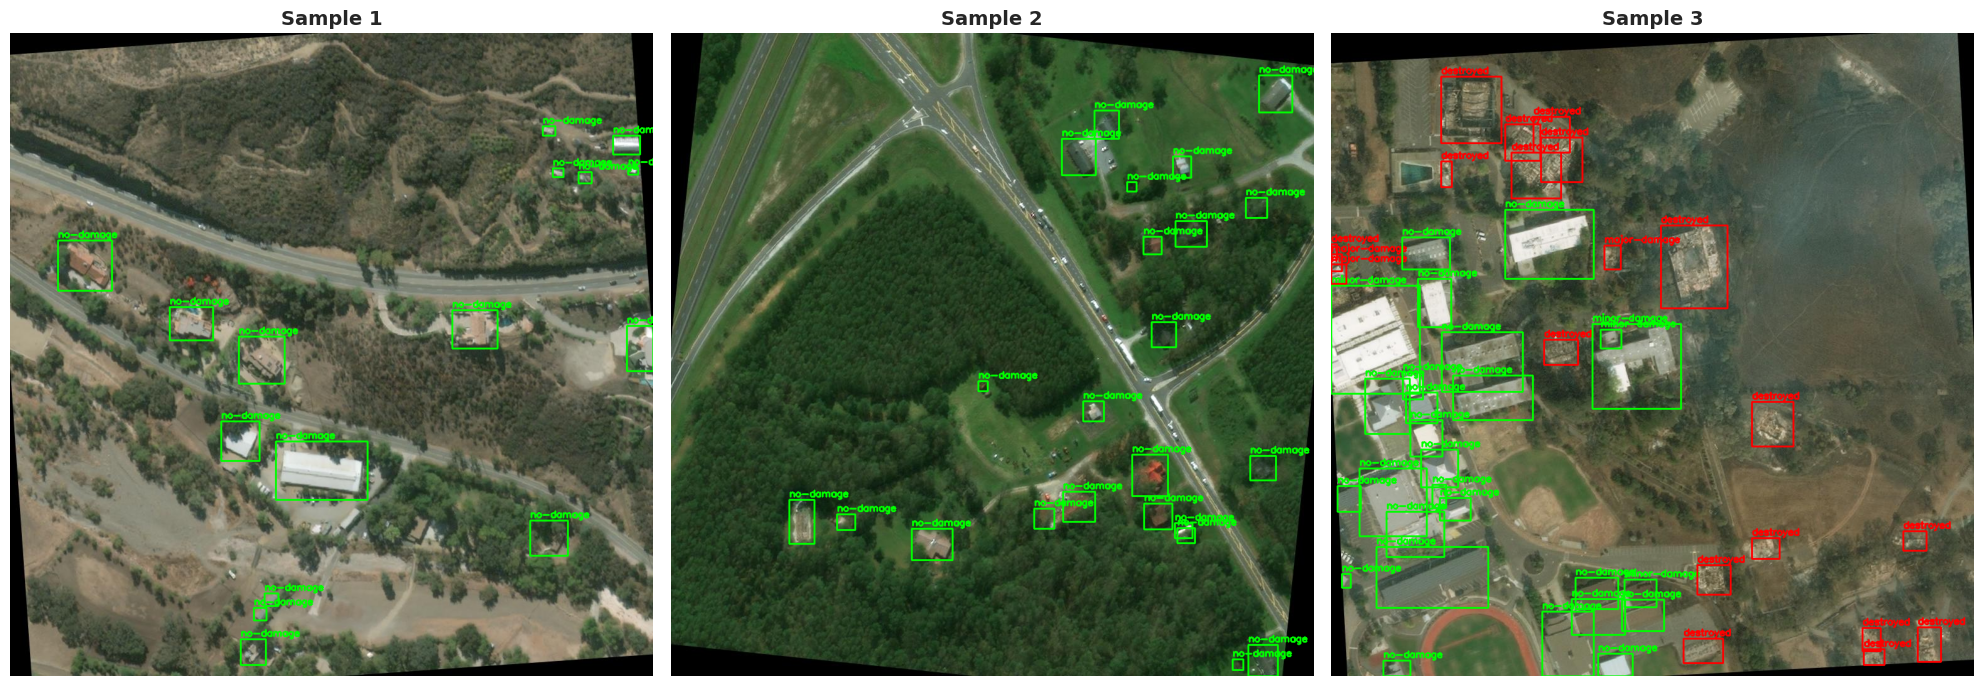

In [5]:
# ==============================================================================
# Visual Verification (Satellite Imagery)
# ==============================================================================
print("👁️ Visualizing Ground Truth Bounding Boxes...")

train_images = glob.glob(f"{dataset.location}/train/images/*.jpg")
if not train_images:
    train_images = glob.glob(f"{dataset.location}/train/images/*.*")

sample_imgs = random.sample(train_images, 3)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, img_path in enumerate(sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                class_name = classes[class_id]

                x_c, y_c, bw, bh = map(float, parts[1:5])
                x1, y1 = int((x_c - bw/2) * w), int((y_c - bh/2) * h)
                x2, y2 = int((x_c + bw/2) * w), int((y_c + bh/2) * h)

                # Draw boxes (Red for destroyed/damaged, Green for safe)
                color = (0, 255, 0) if 'no' in class_name.lower() or 'safe' in class_name.lower() else (255, 0, 0)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                # Put text slightly above the box
                cv2.putText(img, class_name, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i+1}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
# ==============================================================================
# Data Engineering (Class Merging)
# ==============================================================================
print("🛠️ Engineering Data: Merging classes into 'damaged' vs 'safe'...")

yaml_path = f"{dataset.location}/data.yaml"

# 1. Update data.yaml
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['names'] = ['damaged', 'safe']
data_yaml['nc'] = 2

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

# 2. Rewrite the label files
label_files = glob.glob(f"{dataset.location}/**/labels/*.txt", recursive=True)
modified_files = 0

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts: continue

        class_id = int(parts[0])

        # Merge 0, 1, 2 into Class 0 ('damaged')
        if class_id in [0, 1, 2]:
            parts[0] = '0'
        # Change 3 to Class 1 ('safe')
        elif class_id == 3:
            parts[0] = '1'

        new_lines.append(" ".join(parts) + "\n")

    with open(file_path, 'w') as f:
        f.writelines(new_lines)
    modified_files += 1

print(f"✅ Successfully merged classes across {modified_files} files!")
print("🚀 Dataset is now a highly optimized Binary Classification problem.")

🛠️ Engineering Data: Merging classes into 'damaged' vs 'safe'...
✅ Successfully merged classes across 10214 files!
🚀 Dataset is now a highly optimized Binary Classification problem.


In [7]:
# ==============================================================================
# Model Training (TURBO MODE)
# ==============================================================================
print("🚀 Initiating YOLOv8s TURBO Training Pipeline...")

# 1. Load the YOLOv8 Small architecture (Pre-trained weights)
model = YOLO('yolov8s.pt')

# 2. Train the model with our optimized TURBO parameters
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=20,                  # Reduced to 20 to guarantee completion!
    imgsz=640,                  # Standard image size for YOLO
    batch=16,                   # 🔥 Stuffs the GPU to max capacity
    workers=8,                  # 🔥 Uses all CPU cores to fetch data instantly
    cache=True,                 # 🔥 Loads images into RAM to bypass slow Colab hard drive
    patience=5,                 # 🛑 EARLY STOPPING: Abort if no improvement for 5 epochs
    project='Aerial_Damage',    # Folder name for saving results
    name='yolov8s_binary',      # Run name
    plots=True                  # Automatically generate confusion matrices and PR curves
)

print("✅ Training Complete! The Champion Model is saved.")


🚀 Initiating YOLOv8s TURBO Training Pipeline...
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Xview2-XBD-10/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mult

In [15]:
import os
import glob
import shutil

print("🔍 Hunting for your trained model...")

# 1. Find ALL best.pt files anywhere inside the runs folder
best_pt_files = glob.glob('/content/runs/**/best.pt', recursive=True)

if best_pt_files:
    # 2. Grab the most recently created one
    latest_best_pt = max(best_pt_files, key=os.path.getmtime)

    # 3. Copy it to the main folder
    shutil.copy(latest_best_pt, '/content/best.pt')
    print(f"✅ Success! Copied Champion Model from {latest_best_pt} to /content/best.pt")
else:
    print("❌ ERROR: Could not find any 'best.pt' file. Are you sure the training finished in this notebook?")


🔍 Hunting for your trained model...
✅ Success! Copied Champion Model from /content/runs/detect/Aerial_Damage/yolov8s_binary/weights/best.pt to /content/best.pt


In [26]:
%%writefile app.py
import streamlit as st
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import os
import tempfile
from PIL import Image
import numpy as np

st.set_page_config(page_title="Aerial Damage AI", page_icon="🌪️", layout="wide")

# --- 1. CACHE THE MODELS (Massive Speed Boost) ---
@st.cache_resource
def load_models():
    standard_model = YOLO('best.pt')
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type='yolov8',
        model_path='best.pt',
        confidence_threshold=0.30,
        device="cpu" # Safe for free cloud deployment
    )
    return standard_model, sahi_model

standard_model, sahi_model = load_models()

# --- 2. BUILD THE UI ---
st.title("🌪️ Aerial Disaster Response AI")
st.markdown("Upload satellite/drone imagery. The AI uses **SAHI (Slicing Aided Hyper Inference)** to detect damaged vs. safe buildings.")

# Create Tabs
tab1, tab2 = st.tabs(["📸 Image Detection (High Accuracy SAHI)", "🎥 Video Detection (Real-Time YOLO)"])

# --- TAB 1: IMAGE PROCESSING ---
with tab1:
    uploaded_image = st.file_uploader("Upload Drone Image (JPG/PNG)", type=['jpg', 'jpeg', 'png'])

    if uploaded_image is not None:
        image = Image.open(uploaded_image)

        # 🛠️ THE UI UPGRADE: Create two side-by-side columns
        col1, col2 = st.columns(2)

        with col1:
            st.markdown("### Original Image")
            st.image(image, use_container_width=True)

        # Put the button in the middle
        st.markdown("---")
        if st.button("Analyze Damage", type="primary", use_container_width=True):
            with st.spinner("SAHI is slicing and analyzing the image..."):
                img_array = np.array(image)

                # Run SAHI
                result = get_sliced_prediction(
                    img_array,
                    sahi_model,
                    slice_height=320,
                    slice_width=320,
                    overlap_height_ratio=0.2,
                    overlap_width_ratio=0.2
                )

                # SAHI Bug Fix: Save to temp folder, read with OpenCV
                os.makedirs("temp_preds", exist_ok=True)
                result.export_visuals(export_dir="temp_preds", file_name="temp_result", text_size=0.5, rect_th=2)

                annotated_img = cv2.imread("temp_preds/temp_result.png")
                annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

                with col2:
                    st.markdown("### Damage Assessment")
                    st.image(annotated_img, use_container_width=True)
                    st.success("Analysis Complete!")

# --- TAB 2: VIDEO PROCESSING ---
with tab2:
    uploaded_video = st.file_uploader("Upload Drone Video (MP4)", type=['mp4', 'avi', 'mov'])

    if uploaded_video is not None:
        if st.button("Process Video", type="primary"):
            with st.spinner("YOLOv8 is processing the video frame by frame..."):
                tfile = tempfile.NamedTemporaryFile(delete=False, suffix='.mp4')
                tfile.write(uploaded_video.read())

                results = standard_model.predict(
                    source=tfile.name, conf=0.35, iou=0.45, agnostic_nms=True, line_width=2, save=True
                )

                save_dir = results[0].save_dir
                video_name = os.path.basename(tfile.name)
                output_path = os.path.join(save_dir, video_name.rsplit('.', 1)[0] + '.avi')

                st.success("Video Processing Complete!")
                st.video(output_path)

Overwriting app.py


In [25]:
# ==============================================================================
# Dynamic Requirements Generation (Streamlit Version)
# ==============================================================================
import streamlit as st
import ultralytics
import sahi
import cv2
import numpy as np
import PIL

# 1. Grab the exact versions currently running in Colab
st_v = st.__version__
ultra_v = ultralytics.__version__
sahi_v = sahi.__version__
cv2_v = cv2.__version__
numpy_v = np.__version__
pil_v = PIL.__version__

print("🔍 Detected Local Versions:")
print(f"  - streamlit=={st_v}")
print(f"  - ultralytics=={ultra_v}")
print(f"  - sahi=={sahi_v}")
print(f"  - opencv-python-headless=={cv2_v}")
print(f"  - numpy=={numpy_v}")
print(f"  - pillow=={pil_v}")

# 2. Write them directly to requirements.txt
print("\n⚙️ Generating requirements.txt...")
with open('requirements.txt', 'w') as f:
    f.write(f"streamlit=={st_v}\n")
    f.write(f"ultralytics=={ultra_v}\n")
    f.write(f"sahi=={sahi_v}\n")
    f.write(f"opencv-python-headless=={cv2_v}\n")
    f.write(f"numpy=={numpy_v}\n")
    f.write(f"pillow=={pil_v}\n")

print("✅ Success! 'requirements.txt' is perfectly synced with your environment and ready to download.")


🔍 Detected Local Versions:
  - streamlit==1.61.1
  - ultralytics==8.4.117
  - sahi==0.12.5
  - opencv-python-headless==4.10.0
  - numpy==2.0.2
  - pillow==11.3.0

⚙️ Generating requirements.txt...
✅ Success! 'requirements.txt' is perfectly synced with your environment and ready to download.
